Computing a global dendrogram by merging local dendrograms
==========================================================

This notebook explains one algorithm for distributing the dendrogram computation.
The algorithm has the following steps
- distribute the data among processes
- compute local dendrograms on each process in parallel
- gather the local dendrograms on one task
- Further break apart local structures on any extreme points
- recompute the dendrogram, but on the chunks from local structures

This will not scale perfectly because the merging of local dendrograms is a serial bottleneck.
In the worst case, every pixel is its own structure and the full dendrogram is computed from scratch on a single task again, which should take at most twice as long as the serial case.
The algorithm works better, the fewer structures are identified.
This implies few chunks to merge in the serial dendrogram computation.

For example, with $N$ data points, the serial dendrogram needs $N$ iterations.
Splitting the data among $P$ processes, we need $N/P$ iterations on each local task.
Then, we get $M\leq N$ chunks of data that we need to recompute the dendrogram on, requiring another $M$ iterations.
So, the speedup is $S\approx \frac{N}{N/P + M}\geq 1/(P + 1)$.
$M$ depends on $P$ and on how many structures there are in the data.
It remains to be seen how well this performs on real world data.

1D example
----------

Let's start by doing some imports and defining the data

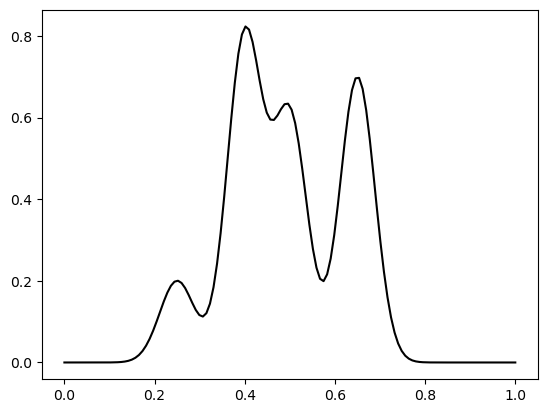

In [1]:
# ruff: noqa: E402
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data
from astrodendro.dendrogram import Dendrogram
from astrodendro.structure import Structure

x, data = get_1d_data(128)
x = x.numpy()
data = data.numpy()

plt.plot(x, data, color="black")

reference_dendrogram = Dendrogram.compute(data)

Next, we are going to split up the data into chunks that we will compute the dendrograms independently on.

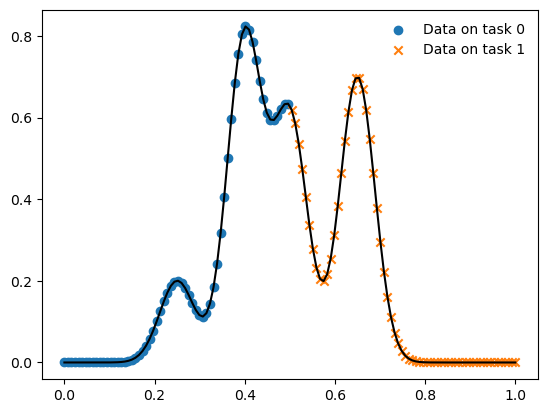

In [2]:
ntasks = 2
elements_per_task = data.shape[0] // ntasks
local_slices = [
    slice(i * elements_per_task, (i + 1) * elements_per_task) for i in range(ntasks)
]


plt.plot(x, data, color="black")
for i, s in enumerate(local_slices):
    marker = "o" if i % 2 == 0 else "x"
    plt.scatter(x[s], data[s], marker=marker, label=f"Data on task {i}")
plt.legend(frameon=False)

Next, we simply compute dendrograms on the local data.
After we have computed them, we add the shift from local data to global data.

In [3]:
local_dendrograms = [Dendrogram.compute(np.array(data[s])) for s in local_slices]

for i, dendrogram in enumerate(local_dendrograms):
    for structure in dendrogram.all_structures:
        structure._indices = np.array(structure._indices) + local_slices[i].start

Let's plot the local dendrograms

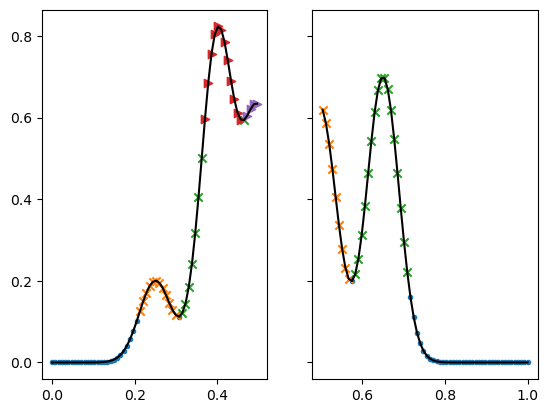

In [4]:
def plot_astrodendro_leaves(ax, leaves, level=0):
    markers = {0: ".", 1: "x", 2: ">", 3: "o", "4": "<"}
    for leaf in leaves:
        ax.scatter(
            np.array(x)[leaf._indices],
            np.array(data)[leaf._indices],
            marker=markers[level],
        )
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)


def plot_local_dendrograms(local_dendrograms):
    fig, axs = plt.subplots(1, ntasks, sharey=True)
    for i in range(ntasks):
        ax = axs[i] if ntasks > 1 else axs
        ax.plot(x[local_slices[i]], data[local_slices[i]], color="black")

        plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)


plot_local_dendrograms(local_dendrograms)

Let's try and merge two adjacent dendrograms
First, we break apart the structures at every extreme point and then we merge them together again later.
This would involve gathering the data in a parallel setup.

In [5]:
all_structures = []
for dendrogram in local_dendrograms:
    all_structures += [me for me in dendrogram.all_structures]

local_extrema = [structure._vmin for structure in all_structures] + [
    structure._vmax for structure in all_structures
]
local_extrema = sorted(local_extrema)

chunks = []
for structure in all_structures:
    indices = np.array(structure._indices)
    values = np.array(structure._values)

    start_idx = local_extrema.index(structure._vmin)
    stop_idx = local_extrema.index(structure._vmax)

    chunk_along = local_extrema[start_idx + 1 : stop_idx]

    if len(chunk_along) == 0:
        chunks.append(indices)
    else:
        for extremum in chunk_along:
            mask = values <= extremum

            chunk = indices[mask]
            if chunk.size != 0:
                chunks.append(chunk)

            indices = indices[~mask]
            values = values[~mask]

        if indices.size != 0:
            chunks.append(indices)

print(
    f"Split the global dendrogram with {data.shape[0]} data points into {len(chunks)} chunks"
)

Split the global dendrogram with 128 data points into 21 chunks


Next, we plot the chunks and the reference diagram side-by-side.

Text(0.5, 1.0, 'Full dendrogram')

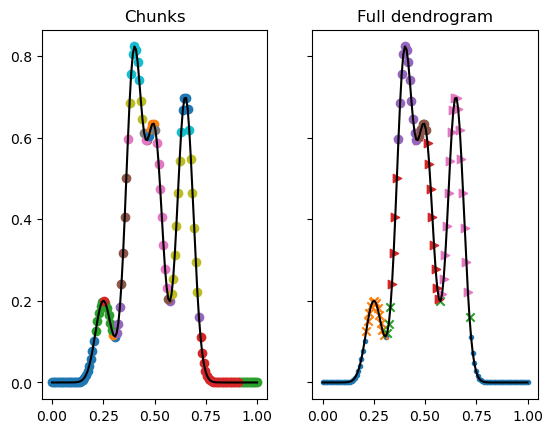

In [6]:
fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].plot(x, data, color="black")
axs[1].plot(x, data, color="black")
for chunk in chunks:
    axs[0].scatter(x[chunk], data[chunk])
plot_astrodendro_leaves(axs[1], reference_dendrogram.trunk)
axs[0].set_title("Chunks")
axs[1].set_title("Full dendrogram")

Looks about right: The chunks are smaller than the structures and no chunk is part of two structures.
We can actually do a rigorous test that this the chunking satisfies this and also covers all data.

In [7]:
assert np.allclose(np.sort(np.concatenate(chunks)[:, 0]), np.arange(data.shape[0]))
for structure in reference_dendrogram.all_structures:
    for chunk in chunks:
        if np.any(np.isin(chunk, structure._indices)):
            assert np.all(np.isin(chunk, structure._indices))

Alright, now we need to merge these chunks to one global dendrogram by following the same rules of the local dendrograms, but applied to the chunks.
Step one is to sort the chunks because we will assemble the tree from the top.

In [8]:
chunk_max_vals = [data[chunk].max() for chunk in chunks]
chunks = [chunks[i] for i in np.argsort(chunk_max_vals)[::-1]]

Before we can assemble the dendrogram, we need to determine whether two chunks are adjacent.

In [9]:
def is_adjacent(chunkA, chunkB):
    if np.any(np.isin(chunkA + 1, chunkB)):
        return True
    elif np.any(np.isin(chunkA - 1, chunkB)):
        return True
    return False

Let's check the function with a few examples

Chunk A is not adjacent to chunk B
Chunk A is adjacent to chunk C


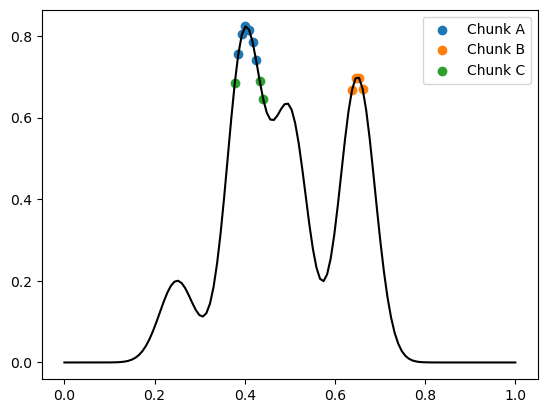

In [10]:
chunkA = chunks[0]
chunkB = chunks[1]
chunkC = chunks[2]

fig, ax = plt.subplots()
ax.plot(x, data, color="black")
ax.scatter(x[chunkA], data[chunkA], label="Chunk A")
ax.scatter(x[chunkB], data[chunkB], label="Chunk B")
ax.scatter(x[chunkC], data[chunkC], label="Chunk C")
ax.legend()

print(f"Chunk A is{'' if is_adjacent(chunkA, chunkB) else ' not'} adjacent to chunk B")
print(f"Chunk A is{'' if is_adjacent(chunkA, chunkC) else ' not'} adjacent to chunk C")
assert not is_adjacent(chunkA, chunkB)
assert is_adjacent(chunkA, chunkC)

Now, we are ready to compute the full dendrogram.
To this end, we loop through all the chunks and assign them to structures.
In each iteration, we do:
- Compute number of adjacent structures we already have in the tree
- If there no adjacent structures, we create a new leaf
- If there is exactly one adjacent structure, we merge the structures
- If there are two adjacent structures, we create a new branch as parent to the two adjacent structures

In [11]:
merged_dendrogram = Dendrogram()


def is_adjacent_to_structure(chunk, structure):
    if is_adjacent(chunk, structure._indices):
        return True
    else:
        return any(
            is_adjacent_to_structure(chunk, child) for child in structure._children
        )


# start with the first leaf
structures = [Structure(chunks[0], data[chunks[0]], dendrogram=merged_dendrogram)]

# loop through all other leafs and assign them to structures
for chunk in chunks[1:]:
    adjacent_structures = [
        structure
        for structure in structures
        if is_adjacent_to_structure(chunk, structure) and structure.parent is None
    ]

    if len(adjacent_structures) == 0:  # create new leaf
        structures.append(Structure(chunk, data[chunk], dendrogram=merged_dendrogram))

    elif len(adjacent_structures) == 1:  # merge into existing structure
        for idx in chunk:
            adjacent_structures[0]._add_pixel(idx, data[idx])

    elif len(adjacent_structures) == 2:  # create parent structure
        structures.append(
            Structure(
                chunk,
                data[chunk],
                children=adjacent_structures,
                dendrogram=merged_dendrogram,
            )
        )

    else:
        raise Exception(
            f"Chunk is adjacent to {len(adjacent_structures)} structures, which is not supposed to happen"
        )

# identify trunk
merged_dendrogram._trunk = [
    structure for structure in structures if structure.parent is None
]

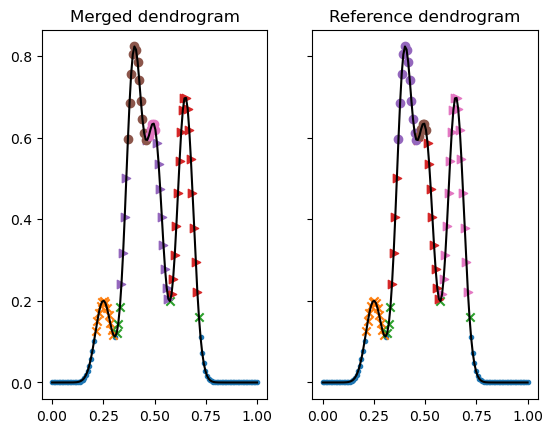

In [12]:
fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].plot(x, data, color="black")
axs[1].plot(x, data, color="black")
plot_astrodendro_leaves(axs[0], merged_dendrogram.trunk)
plot_astrodendro_leaves(axs[1], reference_dendrogram.trunk)
axs[0].set_title("Merged dendrogram")
axs[1].set_title("Reference dendrogram")


def compare_dendrograms(ref_dendrogram, other_dendrogram):
    from dendro.distributed_dendrogram import rows_in

    n_structures1 = len([me for me in ref_dendrogram.all_structures])
    n_structures2 = len([me for me in other_dendrogram.all_structures])
    assert n_structures1 == n_structures2, (
        f"Got {n_structures1} structures in reference dendrogram, but {n_structures2} in other one"
    )

    for structure in ref_dendrogram.all_structures:
        corresponds_to = [
            ref_struct
            for ref_struct in other_dendrogram.all_structures
            if np.any(
                rows_in(np.array(structure._indices), np.array(ref_struct._indices))
            )
        ]
        assert len(corresponds_to) == 1, (
            f"Structure in reference dendrogram corresponds to {len(corresponds_to)} structures in the merged one"
        )
        assert np.allclose(
            np.sort(np.array(structure._indices).flatten()),
            np.sort(np.array(corresponds_to[0]._indices).flatten()),
        ), "Indices dont match between merged and reference structure"


compare_dendrograms(reference_dendrogram, merged_dendrogram)

Success! Now let's try the same thing in 2D.

2D Example
----------
First, we set up some data and compute a reference dendrogram with astrodendro.
Here, we'll use versions of the above functions that are ND compatible and not defined inside this notebook.

In [13]:
from dendro.distributed_dendrogram import DistributedDendrogram
from dendro.utils import get_2d_data

X, Y, data = get_2d_data(64, 3)
X = X.numpy()
Y = Y.numpy()
data = data.numpy()

In [14]:
reference_dendrogram = Dendrogram.compute(data)

Now, we distribute the data along the first axis and compute the local dendrograms

In [15]:
elements_per_task = data.shape[0] // ntasks
local_slices = [
    slice(i * elements_per_task, (i + 1) * elements_per_task) for i in range(ntasks)
]

local_data = [data[local_slice, :] for local_slice in local_slices]

# compute local dendrograms
local_dendrograms = [Dendrogram.compute(_data) for _data in local_data]

# add offsets
for i, dendrogram in enumerate(local_dendrograms):
    for structure in dendrogram.all_structures:
        offset = np.zeros((1, data.ndim), int)
        offset[:, 0] = local_slices[i].start
        structure._indices = np.array(structure._indices) + offset

Let's plot the local and reference dendrograms.

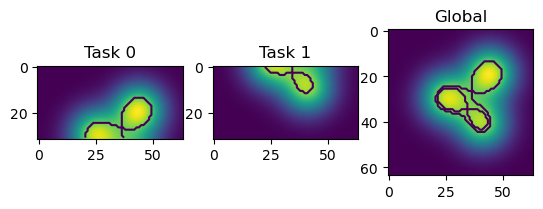

In [16]:
fig, axs = plt.subplots(1, ntasks + 1)


def plot_astrodendro_tree(ax, plotter, leaves):
    for leaf in leaves:
        plotter.plot_contour(ax, structure=leaf)
        plot_astrodendro_tree(ax, plotter, leaf.children)


kwargs = {"vmin": data.min(), "vmax": data.max()}
for i in range(ntasks):
    axs[i].imshow(local_data[i], **kwargs)
    axs[i].set_title(f"Task {i}")
    plot_astrodendro_tree(
        axs[i], local_dendrograms[i].plotter(), local_dendrograms[i].trunk
    )

axs[-1].imshow(data, **kwargs)
axs[-1].set_title("Global")
plot_astrodendro_tree(
    axs[-1], reference_dendrogram.plotter(), reference_dendrogram.trunk
)

Now, we go through the same merging process as before.
First, we gather all structures, then chunk them, and them compute the dendrogram on the chunks.

In [17]:
# gather all structures
all_structures = []
for dendrogram in local_dendrograms:
    all_structures += [me for me in dendrogram.all_structures]

# isolate critical parts from structures
indices = [structure._indices for structure in all_structures]
values = [structure._values for structure in all_structures]

# chunk data
chunks = DistributedDendrogram.chunk_local_structures(indices, values)
chunks = DistributedDendrogram.sort_chunks(chunks, data)

print(
    f"Got {len(chunks)} chunks from {data.size} total data points. This means we can expect a speedup of S={data.size / (data.size / ntasks + len(chunks)):.2f} on {ntasks} tasks"
)

Got 21 chunks from 4096 total data points. This means we can expect a speedup of S=1.98 on 2 tasks


Here are the chunks:

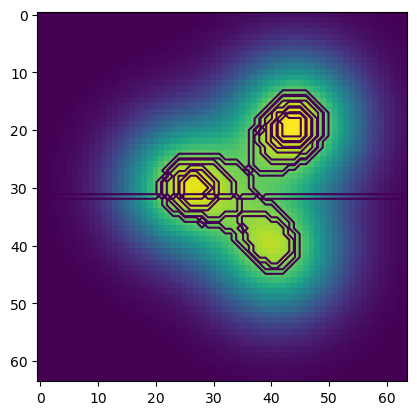

In [18]:
fig, ax = plt.subplots()
ax.imshow(data, **kwargs)
for chunk in chunks:
    _data = np.zeros_like(data)
    _data[*chunk.T] = 10
    ax.contour(_data, levels=[1.0])

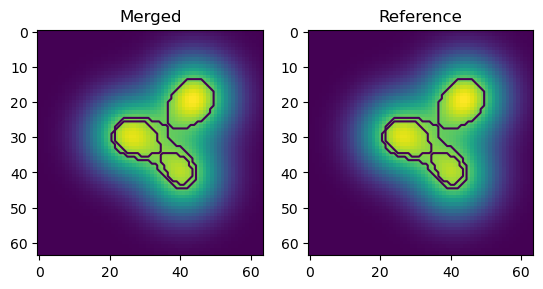

In [19]:
merged_dendrogram = DistributedDendrogram.merge_chunks(chunks, data)

fig, axs = plt.subplots(1, 2)
axs[0].imshow(data, **kwargs)
axs[0].set_title("Merged")
plot_astrodendro_tree(axs[0], merged_dendrogram.plotter(), merged_dendrogram.trunk)
axs[1].imshow(data, **kwargs)
axs[1].set_title("Reference")
plot_astrodendro_tree(
    axs[-1], reference_dendrogram.plotter(), reference_dendrogram.trunk
)

We can see that the dendrograms are the same, which we can also rigorously verify.

In [20]:
compare_dendrograms(reference_dendrogram, merged_dendrogram)

In [21]:
if __name__ == "__main__":
    plt.show()